# Quantiles and seed distributions across datasets

This notebook summarizes one selected metric across seeds for selected models. It reports the 0.25, 0.50, and 0.75 quantiles (25th percentile, median, and 75th percentile), then draws one seed-level boxplot for each of Bio, Blog, SGEMM, QM9, and SCM20D.

Edit the selection cell below and rerun the notebook. Missing datasets, models, metrics, or incomplete seeds are retained as missing table entries and annotated in the plots.

In [23]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display


def find_repository_root(start=Path.cwd()):
    """Find the repository whether Jupyter starts at its root or below it."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file() and (
            candidate / "benchmark"
        ).is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root()
RESULTS_ROOT = REPOSITORY_ROOT / "benchmark/results/10_seeds"
sns.set_theme(style="whitegrid", context="notebook")
REPOSITORY_ROOT

PosixPath('<repository-root>')

## Selections

Choose one metric for the quantile table and any subset of model directory names. The boxplots compare both metrics in `BOXPLOT_METRICS`. Set `SELECTED_MODELS = []` to include every model found below the selected dataset folders.

In [25]:
# DATASET_ORDER = ["bio", "blog", "sgemm", "qm9", "scm20d"]
DATASET_ORDER = ["bio", "blog", "qm9", "scm20d", 'onp']
DATASET_LABELS = {
    "bio": "Bio",
    "blog": "Blog",
    "sgemm": "SGEMM",
    "qm9": "QM9",
    "scm20d": "SCM20D",
    "onp": "ONP",
}

# Common choices: marginal_coverage, worst_slab_coverage,
# excess_coverage_risk, and log_volume_per_dimension.
SELECTED_METRIC = "log_volume_per_dimension"
BOXPLOT_METRICS = [
    "log_volume_per_dimension",
    "excess_coverage_risk",
]

SELECTED_MODELS = [
    "neural_ot_l2",
    "neural_ot_rearranged_l2",
    "realnvp_l2",
    "realnvp_rearranged",
    "realnvp_cdf",
    "realnvp_log_prob",
    "realnvp_rearranged",
    "global_otcp",
    "local_otcp",
    "rf_elliptic",
]

MODEL_LABELS = {
    "rf_elliptic": "Elliptic",
    "global_otcp": "OT-CP",
    "local_otcp": "OT-CP+",
    "neural_ot_l2": "NOT",
    "neural_ot_rearranged_l2": "NOT-R",
    "realnvp_l2": "NF",
    "realnvp_cdf": "HDR-Split",
    "realnvp_log_prob": "CP-Split",
    "realnvp_rearranged": "NF-R",
}
METRIC_LABELS = {
    "marginal_coverage":"Marginal Coverage",
    "worst_slab_coverage":"WSC",
    "excess_coverage_risk":"ECR",
    "log_volume_per_dimension":"LV",
}
BOXPLOT_METRIC_LABELS = {
    "log_volume_per_dimension": "Normalized log-volume",
    "excess_coverage_risk": "Excess coverage risk",
}

SELECTED_METRIC, BOXPLOT_METRICS, SELECTED_MODELS

('log_volume_per_dimension',
 ['log_volume_per_dimension', 'excess_coverage_risk'],
 ['neural_ot_l2',
  'neural_ot_rearranged_l2',
  'realnvp_l2',
  'realnvp_rearranged',
  'realnvp_cdf',
  'realnvp_log_prob',
  'realnvp_rearranged',
  'global_otcp',
  'local_otcp',
  'rf_elliptic'])

## Load seed-level statistics

In [26]:
def metric_mean(metrics, metric_name):
    """Extract the aggregate value stored for one run and metric."""
    metric = metrics.get(metric_name)
    if isinstance(metric, dict):
        metric = metric.get("mean")
    if isinstance(metric, (int, float)) and np.isfinite(metric):
        return float(metric)
    return np.nan


def load_seed_statistics(
    results_root, dataset_order, selected_metrics, selected_models=None
):
    """Load selected aggregate metrics from every completed seed."""
    selected_metrics = list(dict.fromkeys(selected_metrics))
    selected_models = list(selected_models or [])
    selected_model_set = set(selected_models)
    records = []
    missing_folders = []
    missing_metrics = 0

    for dataset in dataset_order:
        dataset_folder = Path(results_root) / dataset
        if not dataset_folder.is_dir():
            missing_folders.append(dataset)
            continue

        for config_path in sorted(dataset_folder.glob("*/seed_*/config.json")):
            model = config_path.parent.parent.name
            if selected_model_set and model not in selected_model_set:
                continue

            metrics_path = config_path.with_name("metrics.json")
            if not metrics_path.is_file():
                missing_metrics += 1
                continue

            config = json.loads(config_path.read_text(encoding="utf-8"))
            metrics = json.loads(metrics_path.read_text(encoding="utf-8"))
            for metric_name in selected_metrics:
                value = metric_mean(metrics, metric_name)
                if not np.isfinite(value):
                    continue

                records.append(
                    {
                        "dataset": dataset,
                        "dataset_label": DATASET_LABELS.get(dataset, dataset),
                        "model": model,
                        "model_label": MODEL_LABELS.get(model, model),
                        "seed": config.get("seed", config_path.parent.name),
                        "metric": metric_name,
                        "value": value,
                    }
                )

    if missing_folders:
        print("No result folder yet for: " + ", ".join(missing_folders))
    if missing_metrics:
        print(f"Skipped {missing_metrics} runs without metrics.json.")

    columns = [
        "dataset",
        "dataset_label",
        "model",
        "model_label",
        "seed",
        "metric",
        "value",
    ]
    return pd.DataFrame.from_records(records, columns=columns)


seed_statistics = load_seed_statistics(
    RESULTS_ROOT,
    DATASET_ORDER,
    [SELECTED_METRIC, *BOXPLOT_METRICS],
    SELECTED_MODELS,
)
print(f"Loaded {len(seed_statistics)} completed seed statistics.")
display(seed_statistics.head(10))

Skipped 1 runs without metrics.json.
Loaded 898 completed seed statistics.


,dataset,dataset_label,model,model_label,seed,metric,value
0,bio,Bio,global_otcp,OT-CP,0,log_volume_per_dimension,4.515608
1,bio,Bio,global_otcp,OT-CP,0,excess_coverage_risk,0.063315
2,bio,Bio,global_otcp,OT-CP,1,log_volume_per_dimension,4.547831
3,bio,Bio,global_otcp,OT-CP,1,excess_coverage_risk,0.065224
4,bio,Bio,global_otcp,OT-CP,2,log_volume_per_dimension,4.538006
5,bio,Bio,global_otcp,OT-CP,2,excess_coverage_risk,0.058197
6,bio,Bio,global_otcp,OT-CP,3,log_volume_per_dimension,4.540070
7,bio,Bio,global_otcp,OT-CP,3,excess_coverage_risk,0.064177
8,bio,Bio,global_otcp,OT-CP,4,log_volume_per_dimension,4.549635
9,bio,Bio,global_otcp,OT-CP,4,excess_coverage_risk,0.058539


## Seed quantiles

The table includes the number of completed seeds and the empirical 25th, 50th, and 75th percentiles of the selected seed statistic.

In [27]:
#  marginal_coverage, worst_slab_coverage,
# # excess_coverage_risk, and log_volume_per_dimension.
# SELECTED_METRIC = "log_volume_per_dimension"

SELECTED_METRIC = "marginal_coverage"

def make_quantile_table(seed_statistics, dataset_order, selected_models=None):
    if seed_statistics.empty:
        return pd.DataFrame(
            columns=["n_seeds", "25% quantile", "50% quantile", "75% quantile"]
        )

    model_order = list(
        dict.fromkeys(selected_models or sorted(seed_statistics["model"].unique()))
    )
    grouped = seed_statistics.groupby(["dataset", "model"])["value"]
    table = grouped.agg(
        n_seeds="count",
        **{
            "25% quantile": lambda values: values.quantile(0.25),
            "50% quantile": lambda values: values.quantile(0.50),
            "75% quantile": lambda values: values.quantile(0.75),
        },
    )
    complete_index = pd.MultiIndex.from_product(
        [dataset_order, model_order], names=["Dataset", "Model"]
    )
    table = table.reindex(complete_index).reset_index()
    table["Dataset"] = table["Dataset"].map(DATASET_LABELS).fillna(
        table["Dataset"]
    )
    table["Model"] = table["Model"].map(MODEL_LABELS).fillna(table["Model"])
    return table.set_index(["Dataset", "Model"])


quantile_seed_statistics = seed_statistics.loc[
    seed_statistics["metric"] == SELECTED_METRIC
]
quantile_table = make_quantile_table(
    quantile_seed_statistics, DATASET_ORDER, SELECTED_MODELS
)
display(
    quantile_table.style.format(
        {
            "n_seeds": "{:.0f}",
            "25% quantile": "{:.6f}",
            "50% quantile": "{:.6f}",
            "75% quantile": "{:.6f}",
        },
        na_rep="--",
    )
)

,n_seeds,25% quantile,50% quantile,75% quantile


In [28]:
seed_statistics["metric"]

0      log_volume_per_dimension
1          excess_coverage_risk
2      log_volume_per_dimension
3          excess_coverage_risk
4      log_volume_per_dimension
                 ...           
893        excess_coverage_risk
894    log_volume_per_dimension
895        excess_coverage_risk
896    log_volume_per_dimension
897        excess_coverage_risk
Name: metric, Length: 898, dtype: str

## Seed distributions by dataset

Rows show log-volume and excess coverage risk; columns follow `DATASET_ORDER`. Each box spans the 25th to 75th percentile, with the median drawn inside it. Model names are shown only on the bottom row.

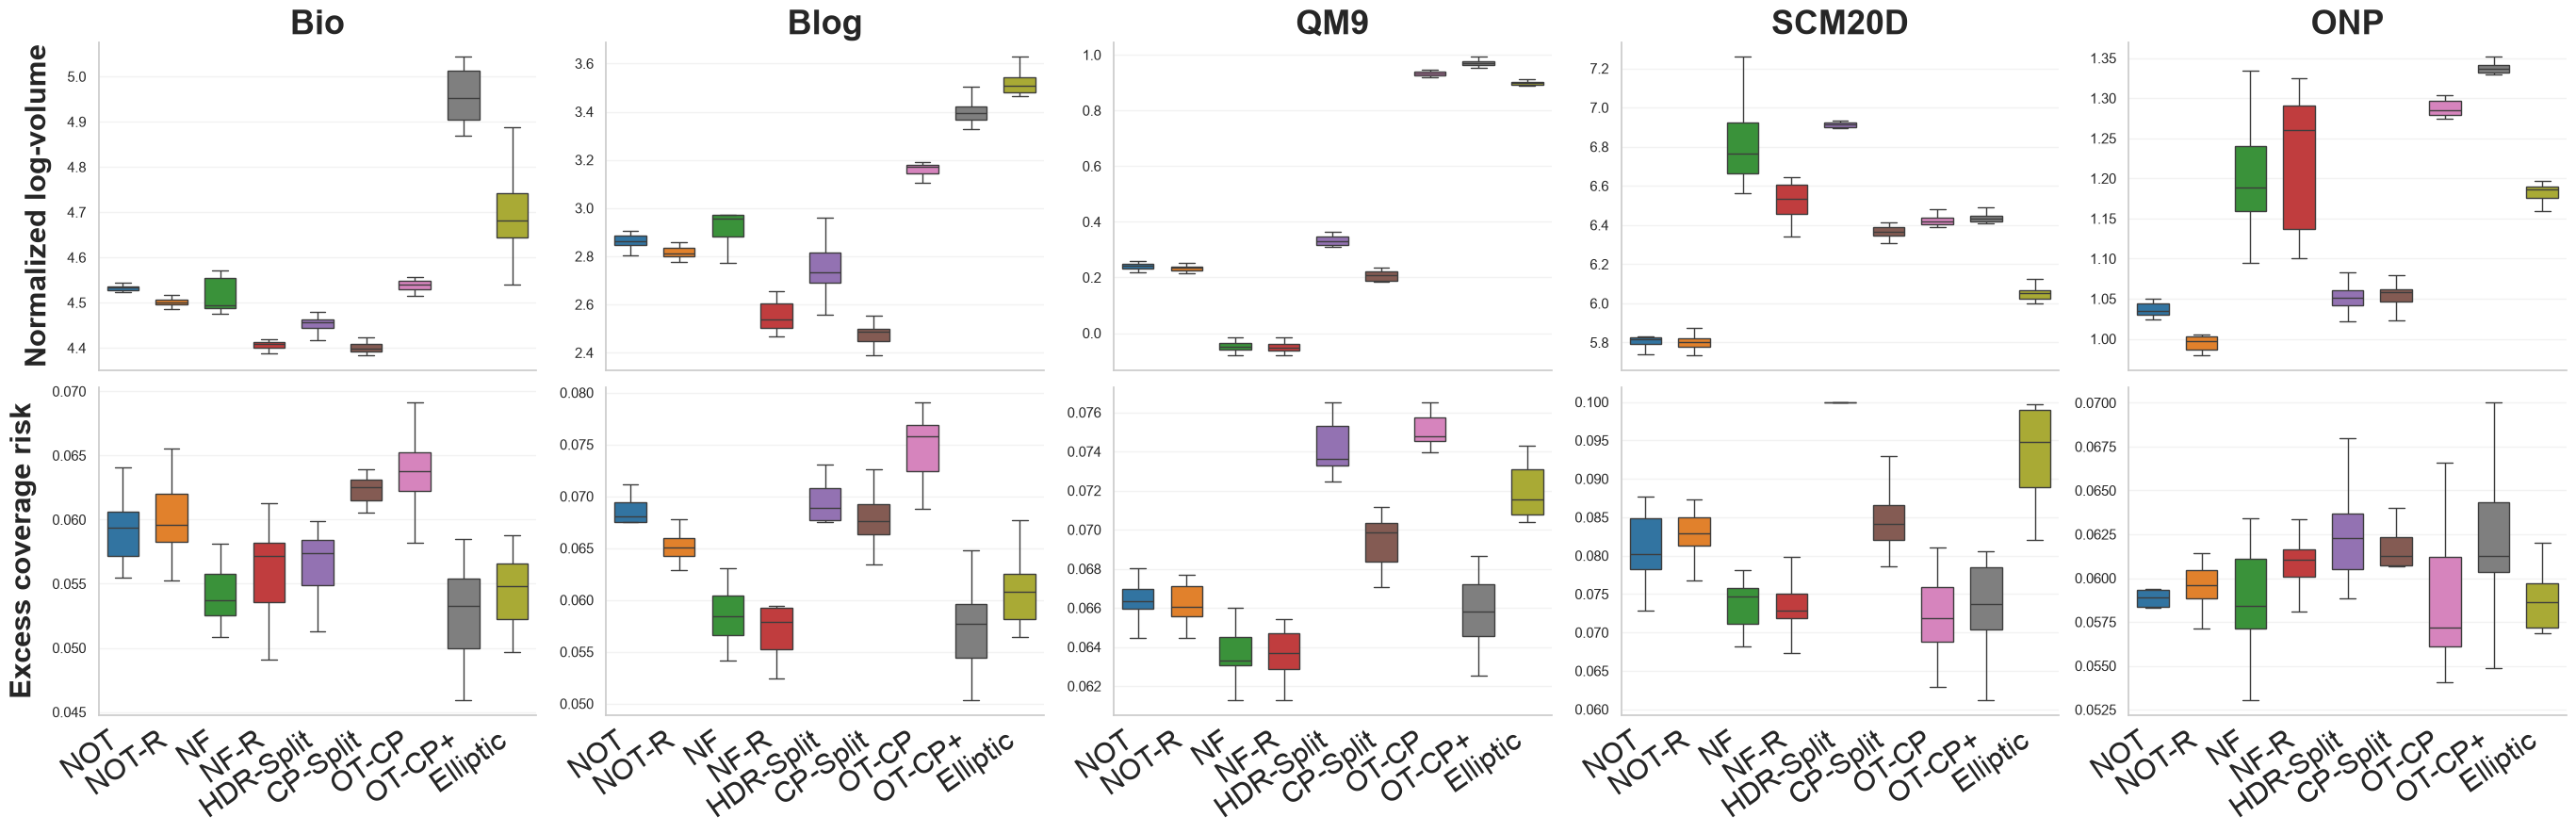

In [29]:
DATASET_NAME_FONTSIZE = 26
X_TICK_FONTSIZE = 22
METRIC_LABEL_FONTSIZE = 22

model_order = list(
    dict.fromkeys(
        SELECTED_MODELS or sorted(seed_statistics["model"].unique())
    )
)
model_label_order = [MODEL_LABELS.get(model, model) for model in model_order]
palette = dict(
    zip(model_label_order, sns.color_palette("tab10", len(model_label_order)))
)

fig, axes = plt.subplots(
    len(BOXPLOT_METRICS),
    len(DATASET_ORDER),
    figsize=(5.5 * len(DATASET_ORDER), 9),
    sharex="col",
    sharey=False,
    squeeze=False,
)

for row_index, metric_name in enumerate(BOXPLOT_METRICS):
    for column_index, dataset in enumerate(DATASET_ORDER):
        axis = axes[row_index, column_index]
        subset = seed_statistics.loc[
            (seed_statistics["dataset"] == dataset)
            & (seed_statistics["metric"] == metric_name)
        ]

        if row_index == 0:
            axis.set_title(
                DATASET_LABELS.get(dataset, dataset),
                fontweight="bold",
                fontsize=DATASET_NAME_FONTSIZE,
            )
        if subset.empty:
            axis.text(
                0.5,
                0.5,
                "No completed results",
                ha="center",
                va="center",
                transform=axis.transAxes,
            )
        else:
            sns.boxplot(
                data=subset,
                x="model_label",
                y="value",
                hue="model_label",
                order=model_label_order,
                hue_order=model_label_order,
                palette=palette,
                width=0.65,
                showfliers=False,
                legend=False,
                ax=axis,
            )

        axis.set_xlabel("")
        if column_index == 0:
            axis.set_ylabel(
                BOXPLOT_METRIC_LABELS.get(
                    metric_name, METRIC_LABELS.get(metric_name, metric_name)
                ),
                fontweight="bold",
                fontsize=METRIC_LABEL_FONTSIZE,
                labelpad=12,
            )
        else:
            axis.set_ylabel("")
        if row_index == len(BOXPLOT_METRICS) - 1:
            axis.tick_params(
                axis="x",
                labelbottom=True,
                labelsize=X_TICK_FONTSIZE,
                rotation=35,
            )
            for label in axis.get_xticklabels():
                label.set_horizontalalignment("right")
        else:
            axis.tick_params(axis="x", labelbottom=False)
        axis.grid(axis="y", alpha=0.25)

sns.despine(fig=fig)
fig.tight_layout(h_pad=1.0, w_pad=1.0)

figures_folder = REPOSITORY_ROOT / "figures"
figures_folder.mkdir(parents=True, exist_ok=True)
fig.savefig(
    figures_folder / "metric_quantiles_log_volume_and_ecr.pdf",
    bbox_inches="tight",
)

plt.show()

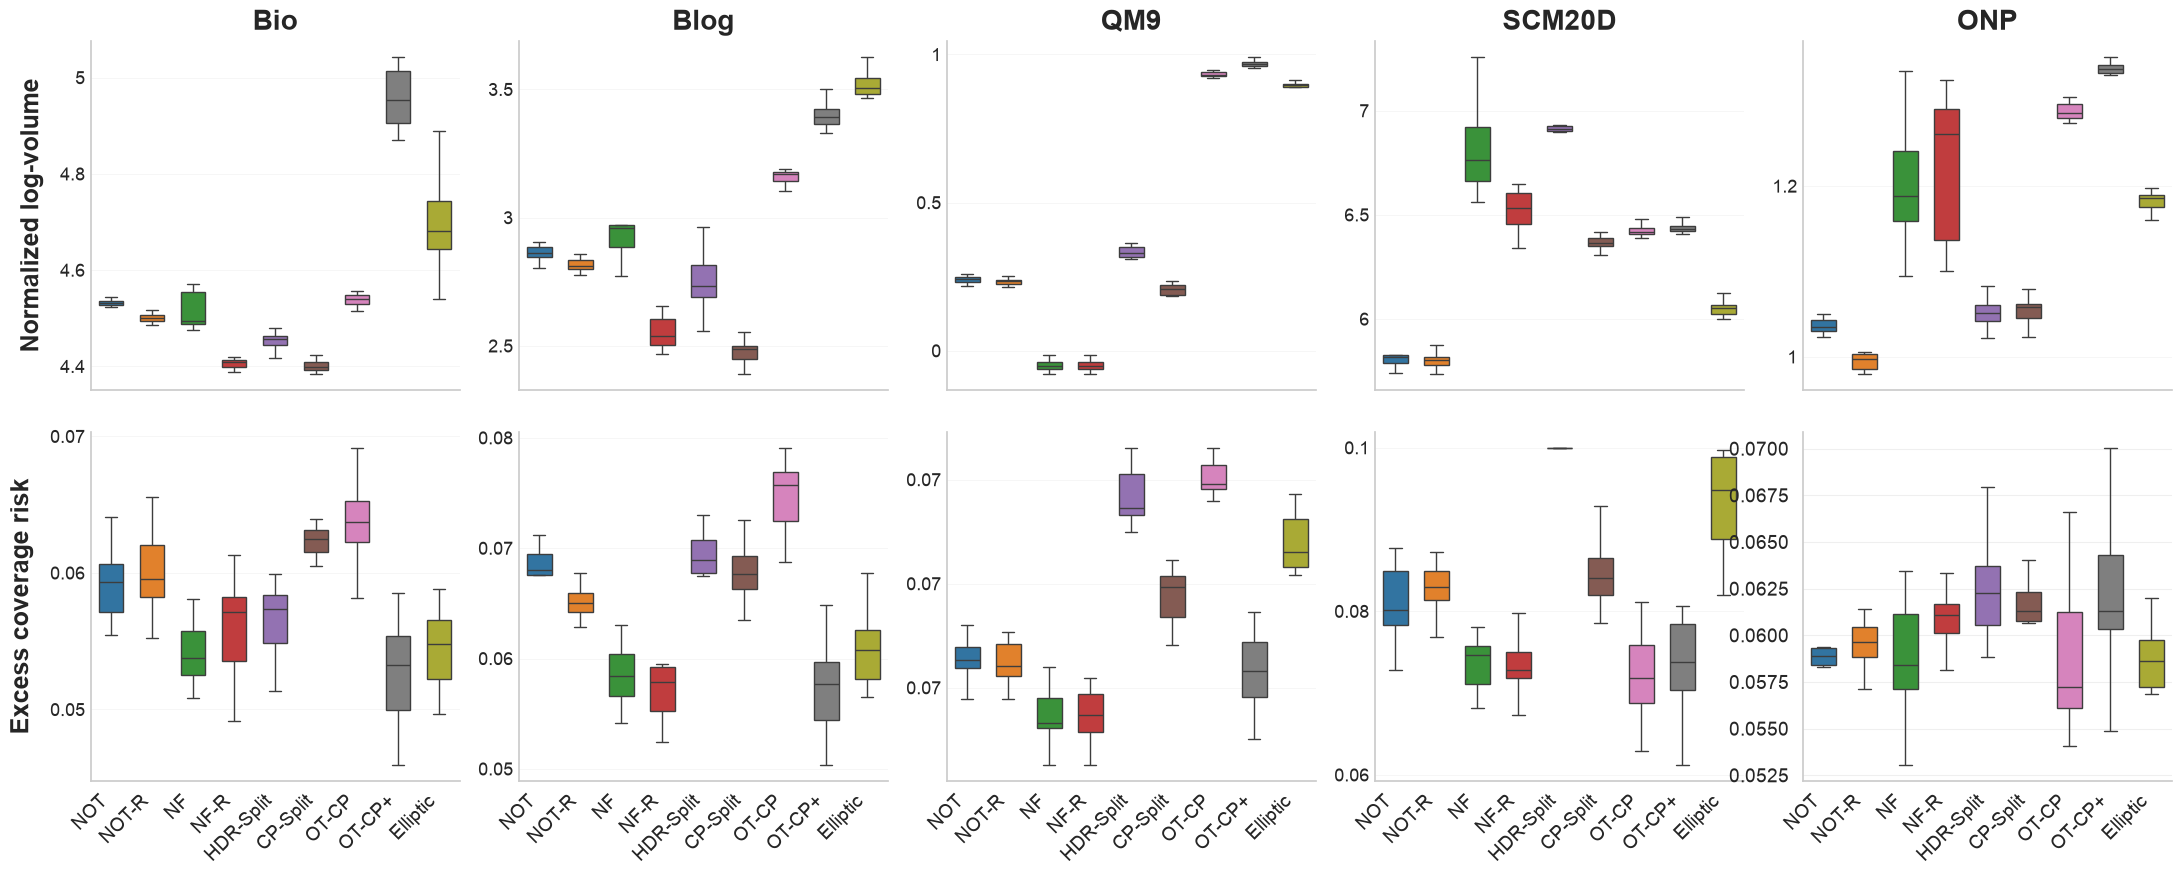

In [36]:

from matplotlib.ticker import MaxNLocator

DATASET_NAME_FONTSIZE = 20
X_TICK_FONTSIZE = 14
Y_TICK_FONTSIZE = 14
METRIC_LABEL_FONTSIZE = 18
from matplotlib.ticker import FuncFormatter

def compact_decimal(x, pos):

    return f"{x:.2f}".rstrip("0").rstrip(".")
    
fig, axes = plt.subplots(
    len(BOXPLOT_METRICS),
    len(DATASET_ORDER),
    figsize=(4.5 * len(DATASET_ORDER), 10),
    sharex="col",
    sharey=False,
    squeeze=False,
)


for row_index, metric_name in enumerate(BOXPLOT_METRICS):
    for column_index, dataset in enumerate(DATASET_ORDER):


                # inside your loop




        axis.yaxis.set_major_formatter(FuncFormatter(compact_decimal))
        axis.yaxis.set_major_locator(

            MaxNLocator(

                nbins=4,

                steps=[1, 2, 2.5, 5, 10],

            )

        )

        axis.tick_params(

            axis="y",

            labelsize=13,

            length=0,

            pad=4,

        )

        axis.grid(

            axis="y",

            alpha=0.18,

            linewidth=0.7,

        )

        axis.set_axisbelow(True)
        axis = axes[row_index, column_index]

        subset = seed_statistics.loc[
            (seed_statistics["dataset"] == dataset)
            & (seed_statistics["metric"] == metric_name)
        ]

        if row_index == 0:
            axis.set_title(
                DATASET_LABELS.get(dataset, dataset),
                fontweight="bold",
                fontsize=DATASET_NAME_FONTSIZE,
                pad=8,
            )

        if subset.empty:
            axis.text(
                0.5,
                0.5,
                "No completed results",
                ha="center",
                va="center",
                transform=axis.transAxes,
            )
        else:
            sns.boxplot(
                data=subset,
                x="model_label",
                y="value",
                hue="model_label",
                order=model_label_order,
                hue_order=model_label_order,
                palette=palette,
                width=0.60,
                showfliers=False,
                legend=False,
                ax=axis,
            )

        axis.set_xlabel("")

        if column_index == 0:
            axis.set_ylabel(
                BOXPLOT_METRIC_LABELS.get(
                    metric_name,
                    METRIC_LABELS.get(metric_name, metric_name),
                ),
                fontweight="bold",
                fontsize=METRIC_LABEL_FONTSIZE,
                labelpad=12,
            )
        else:
            axis.set_ylabel("")

        # Important: explicitly style numerical y ticks
        axis.tick_params(
            axis="y",
            labelsize=Y_TICK_FONTSIZE,
            pad=4,
        )

        if row_index == len(BOXPLOT_METRICS) - 1:
            axis.tick_params(
                axis="x",
                labelbottom=True,
                labelsize=X_TICK_FONTSIZE,
                rotation=45,
                pad=2,
            )

            for label in axis.get_xticklabels():
                label.set_horizontalalignment("right")
        else:
            axis.tick_params(
                axis="x",
                labelbottom=False,
            )

        axis.grid(
            axis="y",
            alpha=0.30,
            linewidth=0.8,
        )
        axis.set_axisbelow(True)

sns.despine(fig=fig)

fig.subplots_adjust(
    left=0.07,
    right=0.995,
    top=0.94,
    bottom=0.20,
    wspace=0.16,
    hspace=0.12,
)

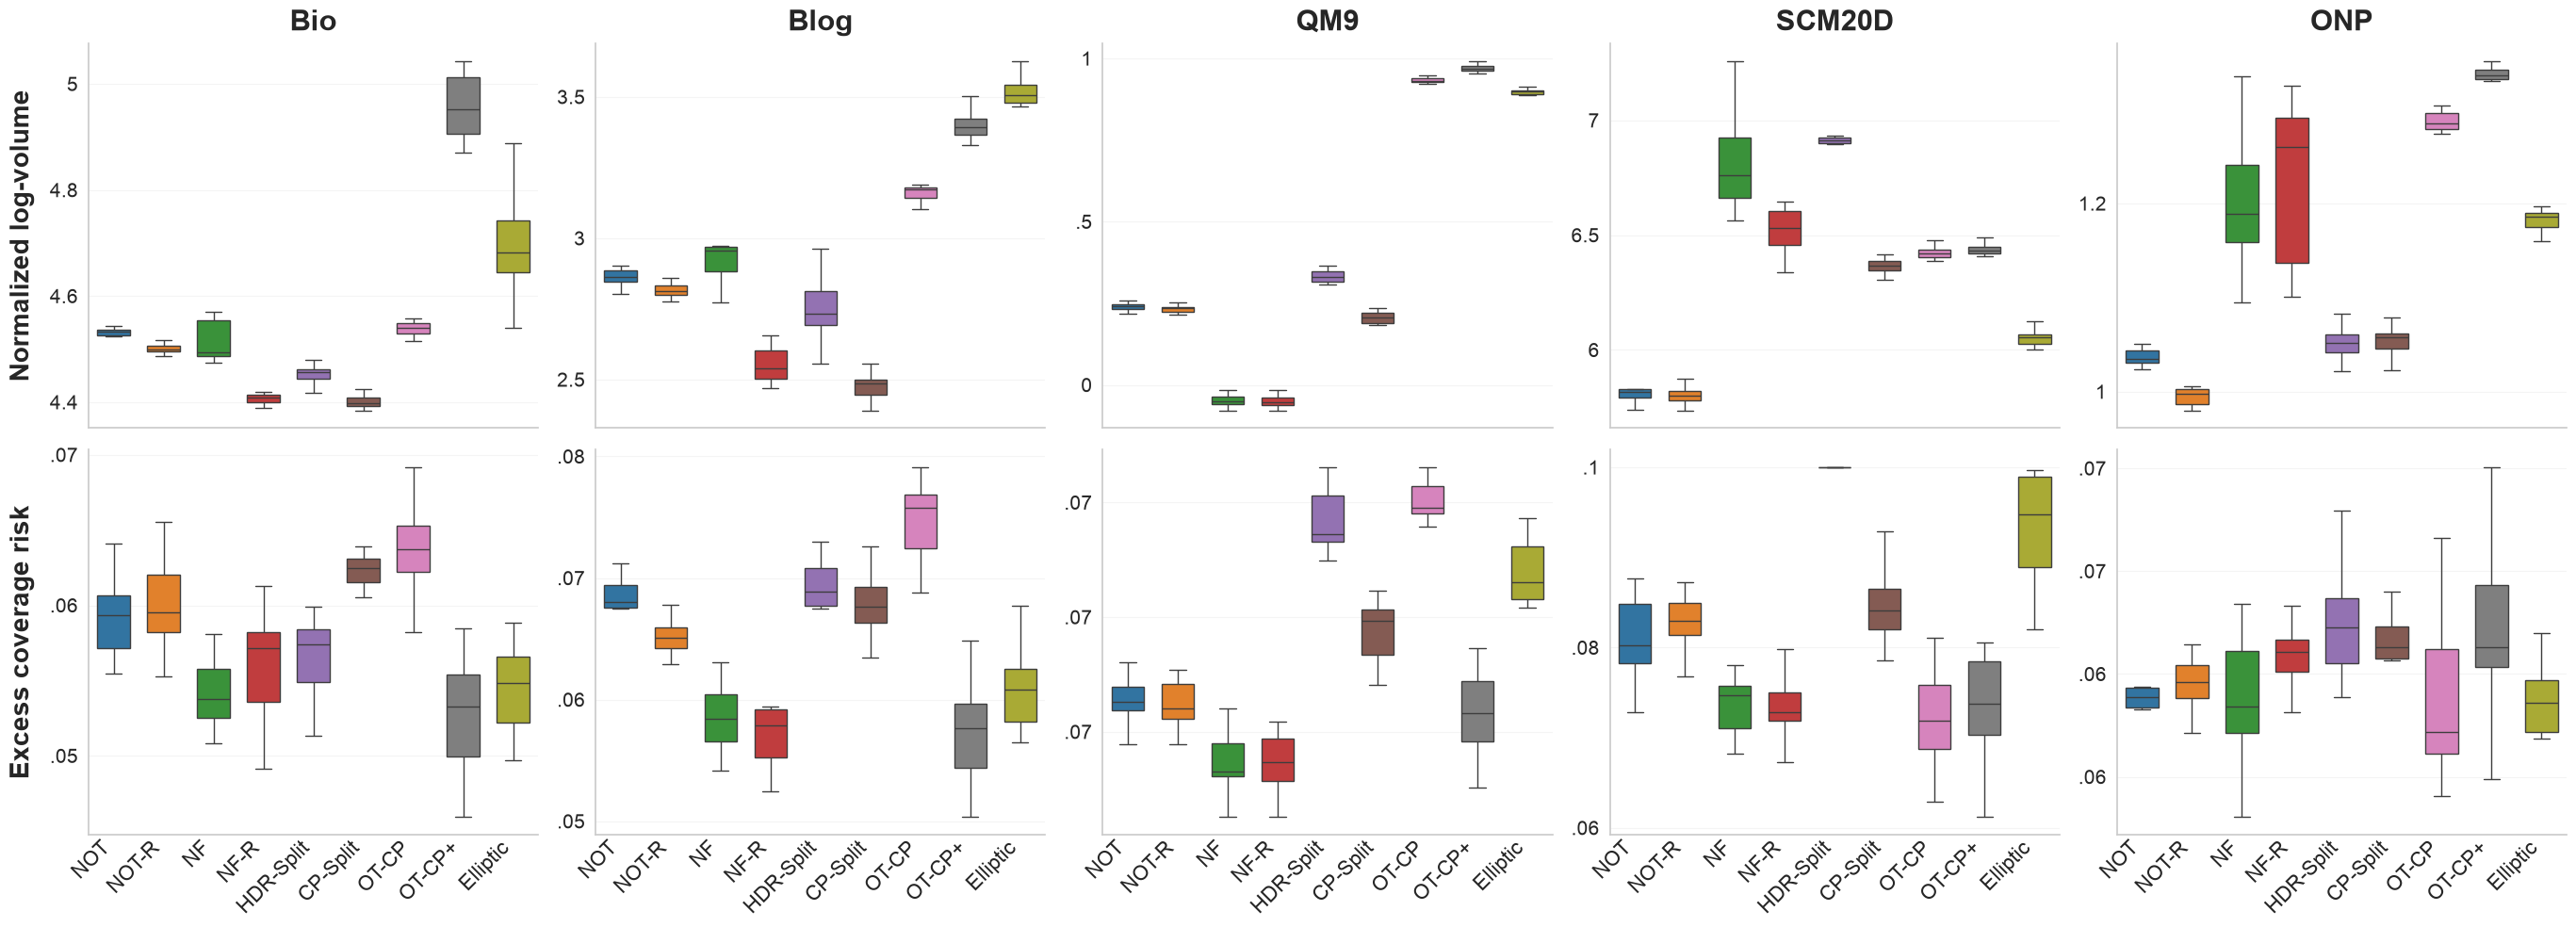

In [39]:
from matplotlib.ticker import FuncFormatter, MaxNLocator


# ------------------------------------------------------------------
# Plot styling
# ------------------------------------------------------------------

DATASET_NAME_FONTSIZE = 22
X_TICK_FONTSIZE = 16
Y_TICK_FONTSIZE = 15
METRIC_LABEL_FONTSIZE = 20


def compact_decimal(x, pos):
    """
    Format tick values compactly:
        0.0700 -> .07
        0.0600 -> .06
        0.5    -> .5
        1.0    -> 1
        4.50   -> 4.5
        5.75   -> 5.75
    """
    s = f"{x:.2f}".rstrip("0").rstrip(".")

    if s.startswith("0."):
        s = s[1:]
    elif s.startswith("-0."):
        s = "-" + s[2:]

    return s


# ------------------------------------------------------------------
# Model ordering and colors
# ------------------------------------------------------------------

model_order = list(
    dict.fromkeys(
        SELECTED_MODELS or sorted(seed_statistics["model"].unique())
    )
)

model_label_order = [
    MODEL_LABELS.get(model, model)
    for model in model_order
]

palette = dict(
    zip(
        model_label_order,
        sns.color_palette("tab10", len(model_label_order)),
    )
)


# ------------------------------------------------------------------
# Figure
# ------------------------------------------------------------------

fig, axes = plt.subplots(
    len(BOXPLOT_METRICS),
    len(DATASET_ORDER),
    figsize=(5.5 * len(DATASET_ORDER), 10),
    sharex="col",
    sharey=False,
    squeeze=False,
)


for row_index, metric_name in enumerate(BOXPLOT_METRICS):

    for column_index, dataset in enumerate(DATASET_ORDER):

        axis = axes[row_index, column_index]

        subset = seed_statistics.loc[
            (seed_statistics["dataset"] == dataset)
            & (seed_statistics["metric"] == metric_name)
        ]

        # ----------------------------------------------------------
        # Dataset title
        # ----------------------------------------------------------

        if row_index == 0:
            axis.set_title(
                DATASET_LABELS.get(dataset, dataset),
                fontweight="bold",
                fontsize=DATASET_NAME_FONTSIZE,
                pad=10,
            )

        # ----------------------------------------------------------
        # Boxplot
        # ----------------------------------------------------------

        if subset.empty:

            axis.text(
                0.5,
                0.5,
                "No completed results",
                ha="center",
                va="center",
                transform=axis.transAxes,
            )

        else:

            sns.boxplot(
                data=subset,
                x="model_label",
                y="value",
                hue="model_label",
                order=model_label_order,
                hue_order=model_label_order,
                palette=palette,
                width=0.65,
                showfliers=False,
                legend=False,
                ax=axis,
            )

        # ----------------------------------------------------------
        # Axis labels
        # ----------------------------------------------------------

        axis.set_xlabel("")

        if column_index == 0:

            axis.set_ylabel(
                BOXPLOT_METRIC_LABELS.get(
                    metric_name,
                    METRIC_LABELS.get(
                        metric_name,
                        metric_name,
                    ),
                ),
                fontweight="bold",
                fontsize=METRIC_LABEL_FONTSIZE,
                labelpad=12,
            )

        else:

            axis.set_ylabel("")

        # ----------------------------------------------------------
        # Y axis
        # ----------------------------------------------------------

        axis.yaxis.set_major_locator(
            MaxNLocator(
                nbins=4,
                steps=[1, 2, 2.5, 5, 10],
            )
        )

        axis.yaxis.set_major_formatter(
            FuncFormatter(compact_decimal)
        )

        axis.tick_params(
            axis="y",
            labelsize=Y_TICK_FONTSIZE,
            length=3,
            pad=5,
        )

        axis.grid(
            axis="y",
            alpha=0.20,
            linewidth=0.8,
        )

        axis.set_axisbelow(True)

        # ----------------------------------------------------------
        # X axis
        # ----------------------------------------------------------

        if row_index == len(BOXPLOT_METRICS) - 1:

            axis.tick_params(
                axis="x",
                labelbottom=True,
                labelsize=X_TICK_FONTSIZE,
                rotation=45,
                length=0,
                pad=3,
            )

            for label in axis.get_xticklabels():
                label.set_horizontalalignment("right")

        else:

            axis.tick_params(
                axis="x",
                labelbottom=False,
                length=0,
            )

        # ----------------------------------------------------------
        # Grid
        # ----------------------------------------------------------

        axis.grid(
            axis="y",
            alpha=0.20,
            linewidth=0.8,
        )

        axis.set_axisbelow(True)


sns.despine(fig=fig)

fig.tight_layout(
    h_pad=1.2,
    w_pad=1.2,
)


# ------------------------------------------------------------------
# Save
# ------------------------------------------------------------------

figures_folder = REPOSITORY_ROOT / "figures"
figures_folder.mkdir(
    parents=True,
    exist_ok=True,
)

fig.savefig(
    figures_folder / "metric_quantiles_log_volume_and_ecr.pdf",
    bbox_inches="tight",
)

plt.show()